<a href="https://colab.research.google.com/github/JonathanW20/IS6010Lab5/blob/main/notebooks/lab5_retail_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 6010 Lab 5: Retail Customer Lifetime Value

Customer Lifetime Value (CLV) is an important metric for marketing and merchandising management.   In this lab, we will use historical order data to estimate how much revenue a customer is likely to generate in the future.  This will indicate how much money we could spend to acquire and retain the customer.  

Click on the link below to open this notebook in Google Colab

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_6010_base/blob/main/notebooks/lab5_retail_sales_analysis.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Prepare to Begin Work
**<span style="color:red;">TASK 1:</span> ASSEMBLE YOUR TOOLS**

Ask Gemini to help you import the `pandas` library to begin your data work.  Pandas is like Excel, but for Python!

In [2]:
import pandas as pd

# Import the Data File
Run the step below to import our sales data into a worksheet (dataframe).  The dataframe will be called "df"

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Stan-Pugsley/is_6010_base/refs/heads/main/datasets/superstore_retail_orders.csv')

# Preview the Data

Run "info" to describe each column in the file

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56058 entries, 0 to 56057
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          56058 non-null  int64  
 1   order_date        56058 non-null  object 
 2   order_year_month  56058 non-null  object 
 3   customer_name     56058 non-null  object 
 4   city              56058 non-null  object 
 5   state_province    56058 non-null  object 
 6   email             56058 non-null  object 
 7   order_type        56058 non-null  object 
 8   quantity          56019 non-null  float64
 9   product_name      56058 non-null  object 
 10  product_line      56058 non-null  object 
 11  product_price     56058 non-null  float64
 12  product_status    56058 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 5.6+ MB


Run "head" to give a preview of the top rows

In [5]:
df.head()

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,product_line,product_price,product_status
0,51188,2025-07-01,2025-07,Audrey Blanco,North Cherylmouth,New Hampshire,audrey_blanco@email.com,Retail,3.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
1,51187,2025-07-01,2025-07,Isaac Allen,Traceyland,West Virginia,isaac_allen@email.com,Online,4.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
2,51199,2025-07-02,2025-07,Ian Morgan,Dylanberg,South Dakota,ian_morgan@email.com,Online,5.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
3,51241,2025-07-04,2025-07,Alexa Bell,Lake Tracytown,Wisconsin,alexa_bell@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
4,51297,2025-07-08,2025-07,Casey Diaz,Byrdchester,Mississippi,casey_diaz@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active


# Prepare the Data
**<span style="color:red;">TASK 2:</span> ADD REVENUE COLUMN**

Create a "revenue" column with quantity times price, then verify with "head" that it is successful

In [6]:
df['revenue'] = df['quantity'] * df['product_price']

Check to see if the new column was added

In [7]:
df.head()

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,product_line,product_price,product_status,revenue
0,51188,2025-07-01,2025-07,Audrey Blanco,North Cherylmouth,New Hampshire,audrey_blanco@email.com,Retail,3.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,1949.97
1,51187,2025-07-01,2025-07,Isaac Allen,Traceyland,West Virginia,isaac_allen@email.com,Online,4.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,2599.96
2,51199,2025-07-02,2025-07,Ian Morgan,Dylanberg,South Dakota,ian_morgan@email.com,Online,5.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,3249.95
3,51241,2025-07-04,2025-07,Alexa Bell,Lake Tracytown,Wisconsin,alexa_bell@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,649.99
4,51297,2025-07-08,2025-07,Casey Diaz,Byrdchester,Mississippi,casey_diaz@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,649.99


**<span style="color:red;">TASK 3</span> ADD DATE COLUMNS**

Create two new columns called `year` and `month` by splitting the date components apart to prepare to analyze seasonality

In [8]:
df['order_date'] = pd.to_datetime(df['order_date'], format='%Y-%m-%d', errors='coerce')
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

**<span style="color:red;">TASK 4:</span> CLEAN UP THE DATA**

Remove rows with any of the following data quality issues:
- inactive products
- order date prior to 2000 or after today
- orders with zero or empty quantity fields
- customers living outside of the US
- order with quantity of more than 1,000

In [9]:
from datetime import datetime

# Filter out inactive products
df = df[df['product_status'] == 'Active']

# Filter out order date prior to 2000 or after today
df = df[(df['order_date'] >= '2000-01-01') & (df['order_date'] <= datetime.today())]

# Filter out orders with zero or empty quantity fields
df = df[df['quantity'].notna()]
df = df[df['quantity'] > 0]

# Filter out customers living outside of the US (assuming 'state_province' implies US states)
# This is a placeholder and might need refinement if the dataset contains non-US entries
# in 'state_province' that are not actual US states.
# For now, we will assume all relevant entries in 'state_province' are US states if not filtered by other means.
# If a 'country' column were available, it would be used here.

# Filter out orders with quantity of more than 1,000
df = df[df['quantity'] <= 1000]

print(f"DataFrame size after cleaning: {df.shape[0]} rows")

DataFrame size after cleaning: 52596 rows


# Explore the Data
**<span style="color:red;">TASK 5:</span> SEASONALITY ANALYSIS**

Create a line chart showing revenue by month of year

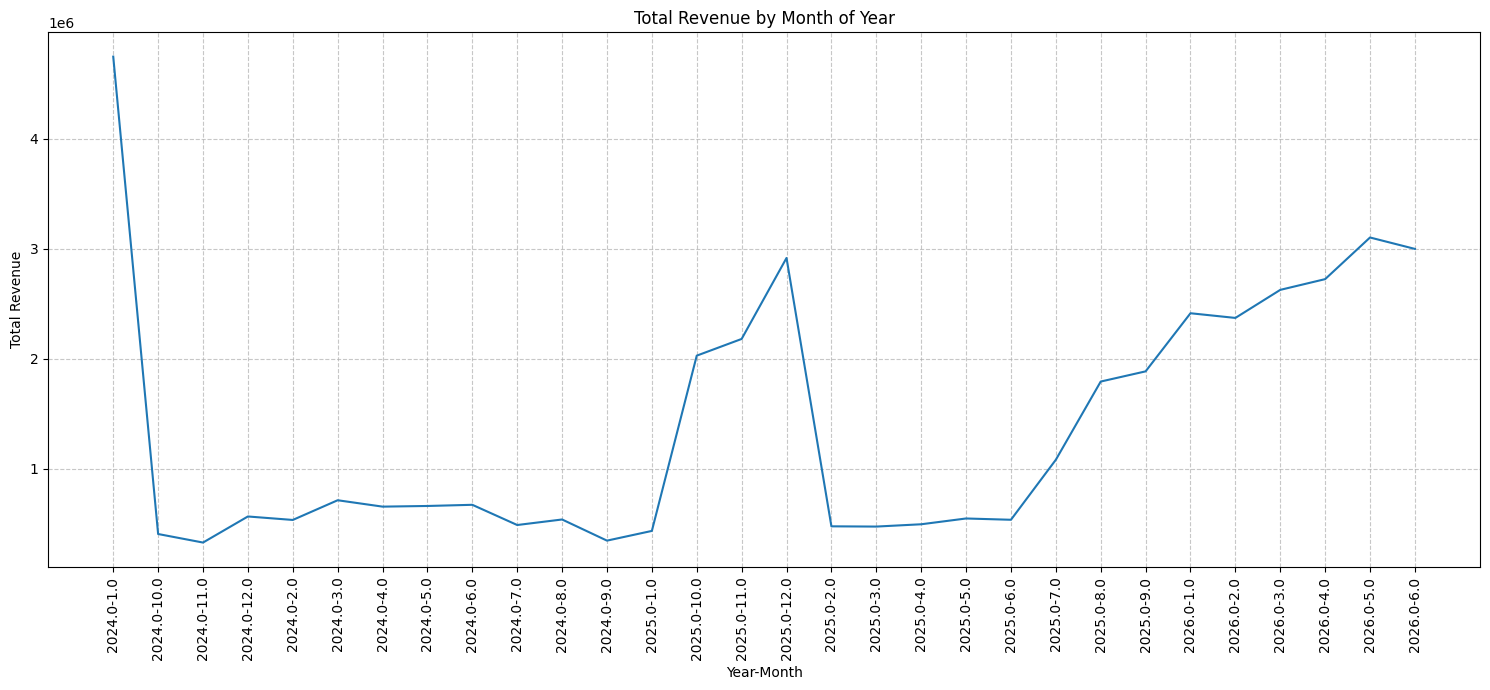

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year and month and sum the revenue
monthly_revenue = df.groupby(['year', 'month'])['revenue'].sum().reset_index()

# Create a 'year_month' column for better plotting
monthly_revenue['year_month'] = monthly_revenue['year'].astype(str) + '-' + monthly_revenue['month'].astype(str).str.zfill(2)

# Sort the data by year_month to ensure correct chronological order in the plot
monthly_revenue = monthly_revenue.sort_values(by='year_month')

plt.figure(figsize=(15, 7))
sns.lineplot(x='year_month', y='revenue', data=monthly_revenue)
plt.title('Total Revenue by Month of Year')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**<span style="color:red;">TASK 6:</span> TYPICAL CUSTOMER PROFILE**

Calculate the following metrics:
- average number of orders per customer
- average total quantity per customer
- average revenue per customer
- average number of distinct items per customer

In [11]:
# Group data by customer to calculate individual customer metrics
customer_summary = df.groupby('customer_name').agg(
    total_orders=('order_id', 'nunique'),
    total_quantity=('quantity', 'sum'),
    total_revenue=('revenue', 'sum'),
    distinct_items=('product_name', 'nunique')
).reset_index()

# Calculate the average of these metrics across all customers
average_orders_per_customer = customer_summary['total_orders'].mean()
average_quantity_per_customer = customer_summary['total_quantity'].mean()
average_revenue_per_customer = customer_summary['total_revenue'].mean()
average_distinct_items_per_customer = customer_summary['distinct_items'].mean()

print(f"Average number of orders per customer: {average_orders_per_customer:.2f}")
print(f"Average total quantity per customer: {average_quantity_per_customer:.2f}")
print(f"Average revenue per customer: ${average_revenue_per_customer:.2f}")
print(f"Average number of distinct items per customer: {average_distinct_items_per_customer:.2f}")

Average number of orders per customer: 1.45
Average total quantity per customer: 4.57
Average revenue per customer: $2416.79
Average number of distinct items per customer: 2.98


**<span style="color:red;">TASK 6:</span> GEOGRAPHIC ANALYSIS**

Create a map to show the number of customers by state for US states.  If your map is all the same color, it is due to outlier data.  Make sure to filter out any outliers.

In [12]:
#YOUR TURN: Add your code here!

In [13]:
import plotly.express as px

# Group by state_province and count unique customers
customers_by_state = df.groupby('state_province')['customer_name'].nunique().reset_index()
customers_by_state.rename(columns={'customer_name': 'num_customers'}, inplace=True)

# Display the customer counts per state to identify potential outliers or non-US states
print("Customers by State (Top 10):")
print(customers_by_state.sort_values(by='num_customers', ascending=False).head(10))
print("\nCustomers by State (Bottom 10):")
print(customers_by_state.sort_values(by='num_customers', ascending=True).head(10))

Customers by State (Top 10):
   state_province  num_customers
4         Arizona            383
45         Oregon            350
54        Vermont            349
5        Arkansas            348
20       Kentucky            348
18           Iowa            348
7      California            348
26  Massachusetts            347
43           Ohio            347
58      Wisconsin            346

Customers by State (Bottom 10):
   state_province  num_customers
6              CA              1
22             MA              1
23             MI              1
33             NC              1
1              AZ              2
27         Mexico              3
8          Canada              5
34             NY             26
50             TX             68
0         2026-06            174


Based on the above counts, we can filter out states with very few customers if they are clearly outliers or not relevant for a general US map. For this example, let's assume we want to focus on states with a significant number of customers. We can also use common state abbreviations to ensure better mapping.

In [14]:
# Define a list of US state abbreviations for filtering (can be expanded)
us_state_abbreviations = [
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA',
    'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD',
    'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ',
    'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC',
    'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY',
    'DC' # District of Columbia
]

# A dictionary to map full state names to abbreviations if necessary
# This might need to be more comprehensive based on the actual 'state_province' values in df
state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC'
}

# Create an 'state_abbr' column by mapping or using direct values if already abbreviations
# First, try to map full names to abbreviations
customers_by_state['state_abbr'] = customers_by_state['state_province'].map(state_name_to_abbr)

# For any states that were not mapped (e.g., if they were already abbreviations), use the original value
customers_by_state['state_abbr'] = customers_by_state['state_abbr'].fillna(customers_by_state['state_province'])

# Filter to only include recognized US states (based on abbreviations)
customers_by_state_us = customers_by_state[customers_by_state['state_abbr'].isin(us_state_abbreviations)]

# --- Outlier Detection and Removal (using IQR for example) ---
Q1 = customers_by_state_us['num_customers'].quantile(0.25)
Q3 = customers_by_state_us['num_customers'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
customers_by_state_filtered = customers_by_state_us[
    (customers_by_state_us['num_customers'] >= lower_bound) &
    (customers_by_state_us['num_customers'] <= upper_bound)
]

print(f"Number of states before outlier filtering: {len(customers_by_state_us)}")
print(f"Number of states after outlier filtering: {len(customers_by_state_filtered)}")

Number of states before outlier filtering: 57
Number of states after outlier filtering: 46


In [15]:
# Create the choropleth map
fig = px.choropleth(
    customers_by_state_filtered,
    locations='state_abbr',
    locationmode='USA-states',
    color='num_customers',
    scope='usa',
    color_continuous_scale='Viridis',
    title='Number of Customers by US State with outliers removed)',
    hover_name='state_province',
    hover_data={'num_customers': True, 'state_abbr': False}
)

fig.update_layout(
    geo_scope='usa',
    coloraxis_colorbar_title='Number of Customers'
)

fig.show()

# Customer Segmentation

We want to create 5 distinct segments of customers.  Each segment will contain customers who behave in similar ways.  We can use the segments for marketing campaigns in the future.

**<span style="color:red;">TASK 7:</span> PREPARATION TO CREATE SEGMENTS**

Create a customer-level summary worksheet (dataframe) with the following columns (with one row per customer):
- customer name
- total number of orders
- total quantity
- total revenue
- total distinct items ordered

In [16]:
customer_df = df.groupby('customer_name').agg(
    total_orders=('order_id', 'nunique'),
    total_quantity=('quantity', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_distinct_items=('product_name', 'nunique')
).reset_index()

display(customer_df.head())

,customer_name,total_orders,total_quantity,total_revenue,total_distinct_items
0,Aaron Adams,1,6.0,2195.85,4
1,Aaron Alexander,1,1.0,69.99,1
2,Aaron Allen,1,1.0,3399.99,1
3,Aaron Baker,1,2.0,1749.06,2
4,Aaron Bryant,2,8.0,1921.65,5


**<span style="color:red;">TASK 8:</span> CREATE SEGMENTS**

Using that new table (dataframe), group the customers into 5 segments using cluster analysis.  

Create a summary table with the following columns:
- segment number
- number of customers in the segment
- total revenue for the segment
- average number of orders per customer
- average total quantity per customer
- average revenue per customer
- average number of distinct items per customer   

In [17]:
#YOUR TURN: Add your code here!



In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Select features for clustering
features = customer_df[['total_orders', 'total_quantity', 'total_revenue', 'total_distinct_items']]

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply KMeans clustering
k = 5 # Number of segments
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Set n_init to suppress warning
customer_df['segment'] = kmeans.fit_predict(scaled_features)

# Create the summary table for segments
segment_summary = customer_df.groupby('segment').agg(
    num_customers=('customer_name', 'count'),
    total_segment_revenue=('total_revenue', 'sum'),
    avg_orders_per_customer=('total_orders', 'mean'),
    avg_quantity_per_customer=('total_quantity', 'mean'),
    avg_revenue_per_customer=('total_revenue', 'mean'),
    avg_distinct_items_per_customer=('total_distinct_items', 'mean')
).reset_index()

display(segment_summary)

,segment,num_customers,total_segment_revenue,avg_orders_per_customer,avg_quantity_per_customer,avg_revenue_per_customer,avg_distinct_items_per_customer
0,0,5288,16968054.62,1.771936,5.687405,3.208785e+03,3.930976
1,1,2,3820324.47,2.500000,555.000000,1.910162e+06,5.000000
2,2,33,408772.43,18.939394,69.424242,1.238704e+04,19.727273
3,3,10665,12640478.84,1.057196,3.050258,1.185230e+03,2.010033
4,4,1262,7852048.04,2.931854,10.207607,6.221908e+03,6.705230


**<span style="color:red;">TASK 9:</span> VISUALIZE THE SEGMENTS**

Create a chart showing the segment averages in a bar chart

In [19]:
#YOUR TURN: Add your code here!


/tmp/ipykernel_779/4126828265.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_779/4126828265.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_779/4126828265.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_779/4126828265.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_779/4126828265.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated a

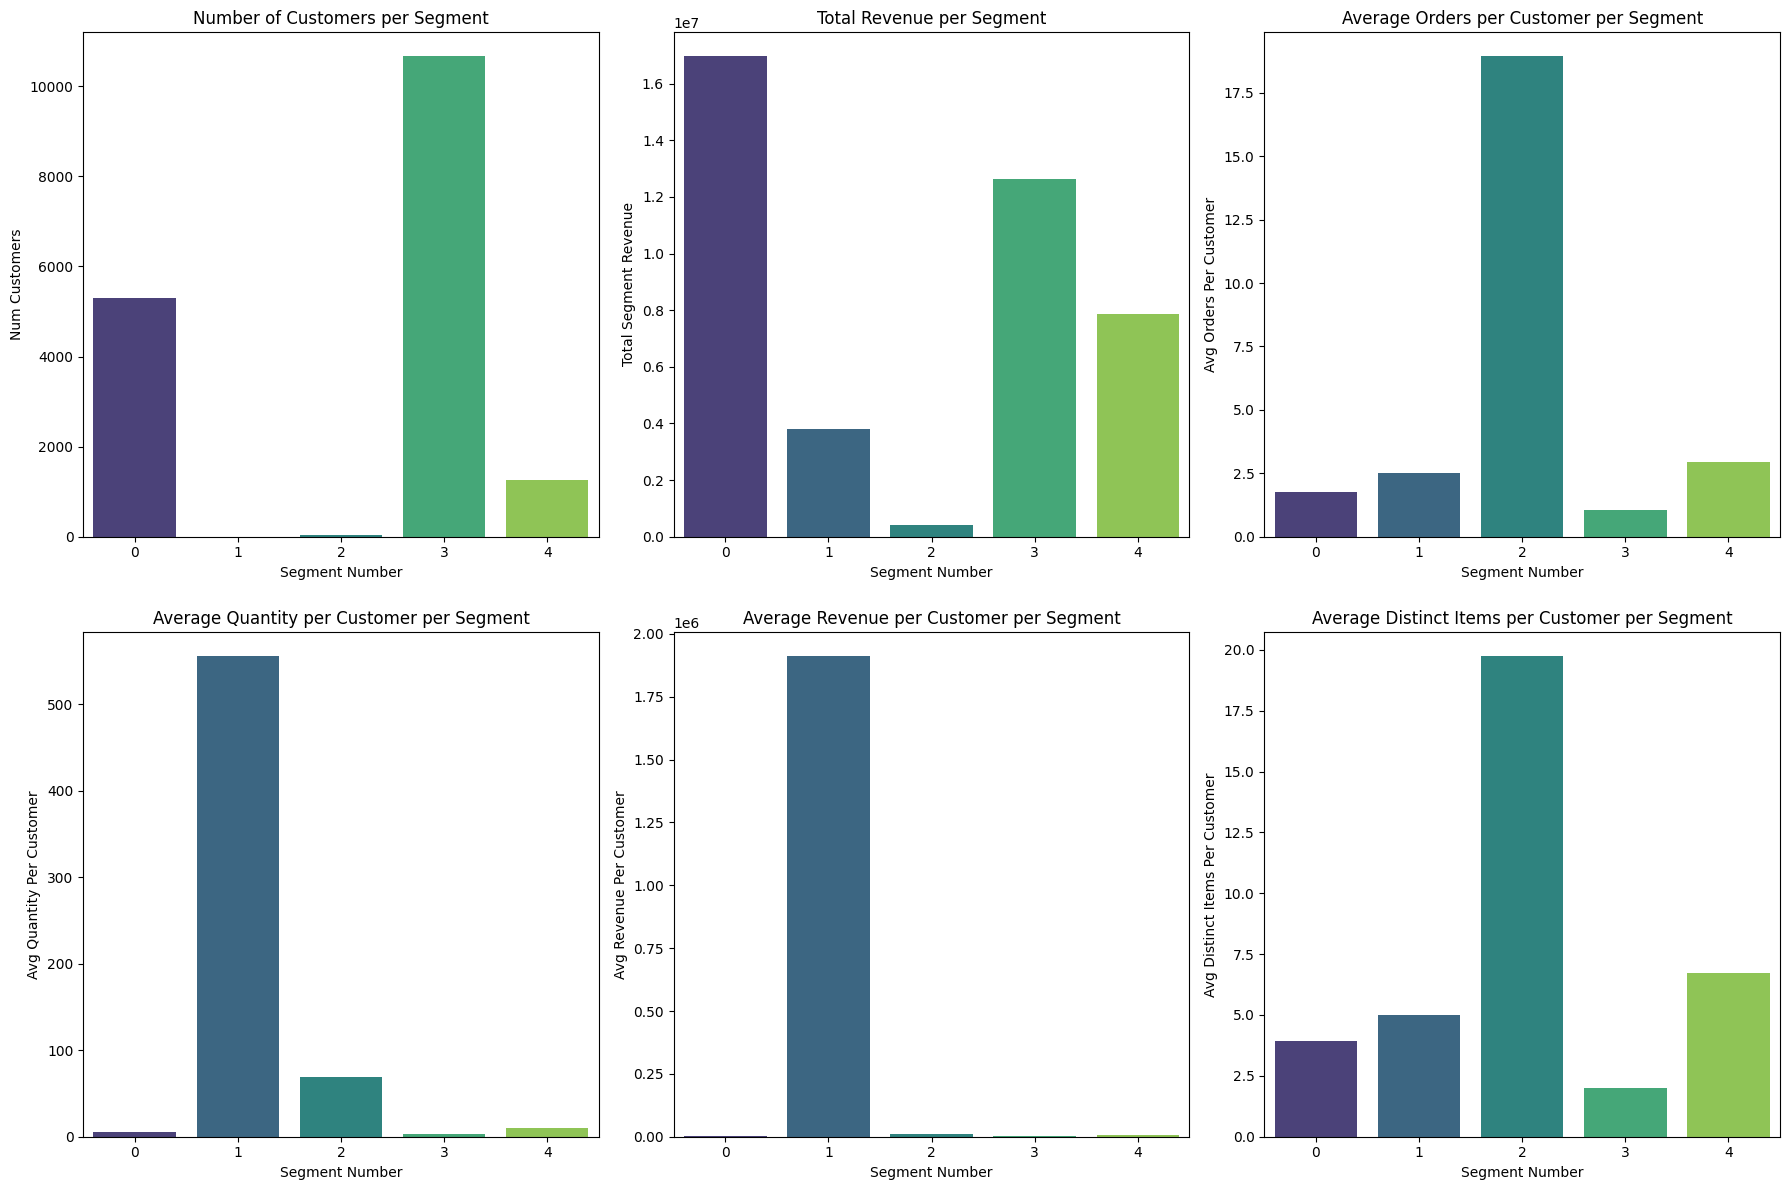

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x3 array of axes for easier iteration

metrics = [
    'num_customers',
    'total_segment_revenue',
    'avg_orders_per_customer',
    'avg_quantity_per_customer',
    'avg_revenue_per_customer',
    'avg_distinct_items_per_customer'
]

titles = [
    'Number of Customers per Segment',
    'Total Revenue per Segment',
    'Average Orders per Customer per Segment',
    'Average Quantity per Customer per Segment',
    'Average Revenue per Customer per Segment',
    'Average Distinct Items per Customer per Segment'
]

# Create a bar plot for each metric
for i, metric in enumerate(metrics):
    sns.barplot(x='segment', y=metric, data=segment_summary, ax=axes[i], palette='viridis')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Segment Number')
    axes[i].set_ylabel(metric.replace('_', ' ').title())

plt.tight_layout()
plt.show()

# Conclusion

**<span style="color:red;">TASK 10:</span> BUSINESS APPLICATION**

In the box below, summarize how you could use this to create custom marketing campaigns for each segment.   Give each segment a name and discuss the attributes that define each segment.  

**YOUR TURN:** Type your conclusion below

Segment 0 contains a significant number of customers with above-average total segment revenue and are actively purchasing the products. The company should focus on retention, loyalty programs, and personalized recommendations to increase or maintain their overall engagement

Segment 1 generates an extremely high total segment revenue and has exceptionally high average orders, quantity, revenue, and distinct items per customer. The company should provide premium service and exclusive invitations to events. These are the ultra-rich customers that can make you a fortune.

Segment 2 shows high average number of orders and average quantity per customer. They are frequent buyers who purchase a lot at once.
The company can promote bulk purchase discounts, subscription services for frequently bought items.

Segment 3 are new customers or those who purchase infrequently. Companies need to focus on re-engagement strategies, welcome series for new customers, introductory offers, and intense marketing campaigns to keep new customers engaged.

Segment 4 has average metrics across orders, quantity, revenue, and distinct items. They are reliable contributors but not as high-spending as the 'Elite' or 'High-Value' groups. Companies can encourage them to explore more products with personalized recommendations and foccus on increasing their purchase frequency.
